In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from figures_setup import *
from utils import set_color_code

## Get data from arrayExpress: biobank subcut epi

In [12]:
# Download data from arrayExpress and reassemble anndata object
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16585"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16585 in: ../data_arrayExpress/E-MTAB-16585
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16585
      Inferred 2 dataset representations:
      - epi (full prefix: biobank_subcut_epi)
      - full (full prefix: biobank_subcut_full)
      Selected dataset for in-memory loading: epi (full prefix: biobank_subcut_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_full.h5ad
      Loading selected dataset from disk: E-MTAB-16585/E-MTAB-16585_epi.h5ad


AnnData object with n_obs × n_vars = 10135 × 27111
    obs: 'sample_id', 'donor_id', 'library_id', 'batch', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

In [ ]:
# # Read input data
# previously dir_data set to ../data/ in figures_setup.py
# file = os.path.join(dir_data, "biobank_subcut_epi.h5ad")
# adata = sc.read_h5ad(file)

## Annotation

In [ ]:
# # Add annotation
# from utils_biobank_subcut import anno_leiden_dict_epi as anno_leiden_dict

# if adata.uns['leiden']['params']['resolution'] == anno_leiden_dict['resolution']:
#     adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# else:
#     raise ValueError("Resolution mismatch between adata.uns['leiden'] and anno_leiden_dict.")

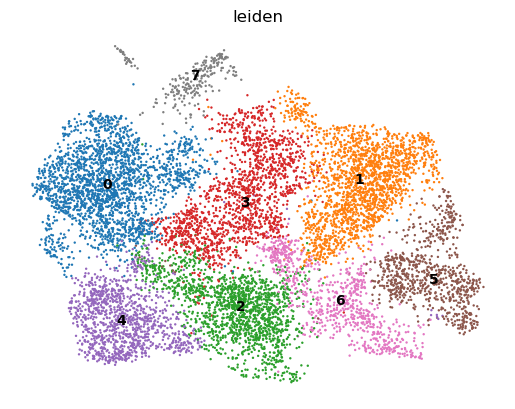

In [35]:
# Ensure order of leiden clustering (str) is available
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
sc.pl.umap(adata, color='leiden', legend_loc='on data', show=True, frameon=False)

In [36]:
# Add annotation to dataset
from utils_biobank_subcut import anno_leiden_dict_epi as anno_leiden_dict

adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# Order annotation levels by leiden cluster number
adata.obs['anno'] = pd.Categorical(
    adata.obs['anno'],
    categories=[anno_leiden_dict['labels'][f'{i}'] for i in range(len(anno_leiden_dict['labels']))],
    ordered=True
)

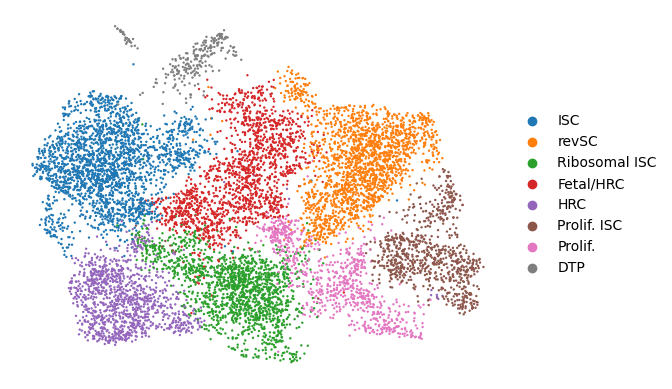

In [37]:
# Annotation UMAP
sc.pl.umap(adata, color=['anno'], frameon=False, title='')

In [38]:
### Infer cell cycle phase
import utils_genelist as genelist

print("Infer cell cycle phase...")
# Get cell-cycle related gene sets
geneset = genelist.get_Tirosh_2016()
sc.tl.score_genes_cell_cycle(adata, 
                        s_genes=genelist.strip_gene_list(geneset['G1/S']), 
                        g2m_genes=genelist.strip_gene_list(geneset['G2/M']))

Infer cell cycle phase...


/omics/groups/OE0285/internal/puschhof/github_projects/TROP2_in_CRC/figures/utils_genelist.py:25: UserWarning: Removed columns containing only NaNs: Unnamed: 7, Unnamed: 8, Unnamed: 9, Unnamed: 10, Unnamed: 11, Unnamed: 12, Unnamed: 13, Unnamed: 14, Unnamed: 15, Unnamed: 16
  warnings.warn(f"Removed columns containing only NaNs: {', '.join(cols_to_remove)}")


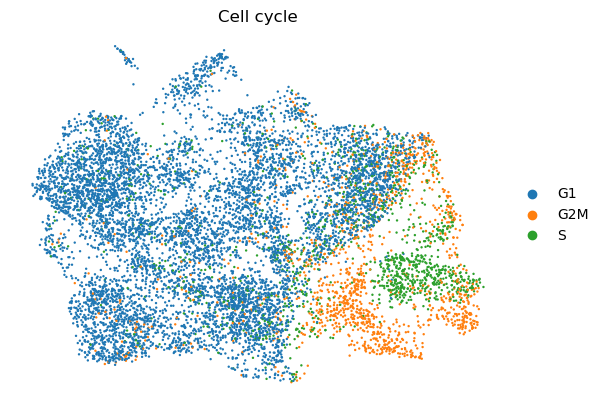

In [39]:
# Cell cycle UMAP
sc.pl.umap(adata, color=['phase'], frameon=False, title='Cell cycle')

## Gene expression UMAP

UMAPs of gene expression patterns:


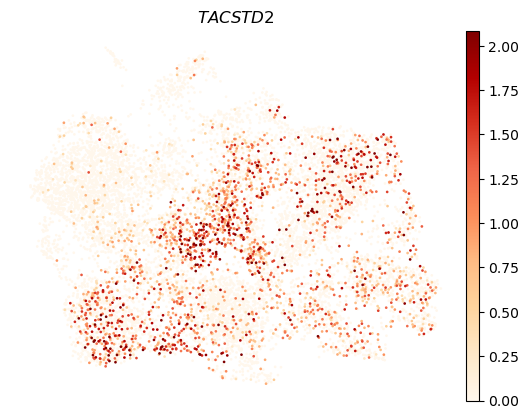

<Figure size 640x480 with 0 Axes>

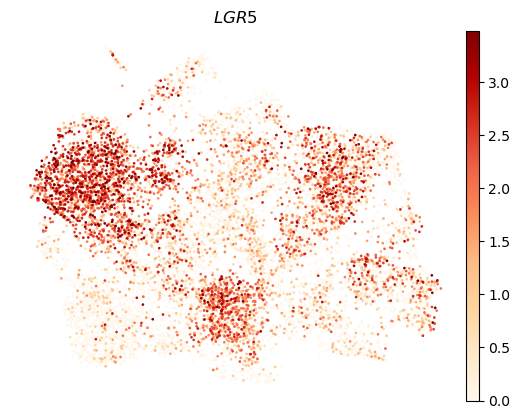

<Figure size 640x480 with 0 Axes>

In [41]:
# Features to plot
features = ['TACSTD2', 'LGR5']

# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        size=dot_size, 
        cmap='OrRd', 
        vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    plt.tight_layout()
    plt.show()

## Gene set activation scores

In [61]:
# Import literature gene sets to adata.uns
from utils import get_gene_sets
print("Importing gene sets into anndata object...")
adata = get_gene_sets(adata, verbose=False)

Importing gene sets into anndata object...


In [55]:
# Compute gene set scores
gs_process = ['score_fetal', 'score_Lgr5', 'score_epiHR']
feature_labels = {
    'score_fetal': 'Fetal',
    'score_Lgr5': 'ISC',
    'score_epiHR': 'EpiHR',
}

import utils_genelist as genelist

gene_sets = adata.uns['gene_sets']
for score_name in gs_process:
    genes = gene_sets[gene_sets['gene_set'] == score_name]['gene']
    adata = genelist.compute_gene_score(adata, genes, score_name=score_name, layer='log1p')

Copying log1p to adata.X for gene score computation...
Computing gene score for score_fetal
Restoring original matrix X.
Copying log1p to adata.X for gene score computation...
Computing gene score for score_Lgr5
Restoring original matrix X.
Copying log1p to adata.X for gene score computation...
Computing gene score for score_epiHR
Restoring original matrix X.


UMAPs of gene set scores:


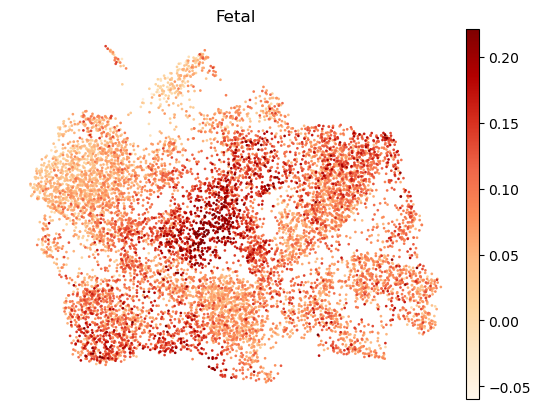

<Figure size 640x480 with 0 Axes>

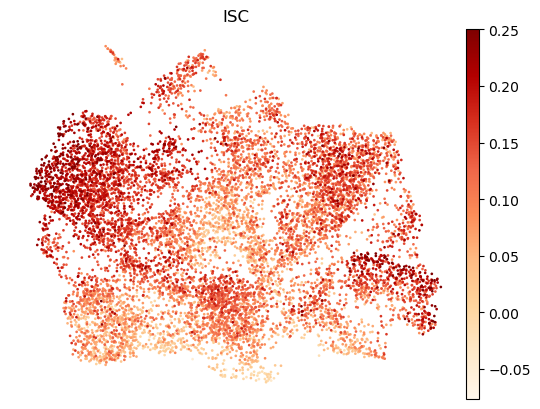

<Figure size 640x480 with 0 Axes>

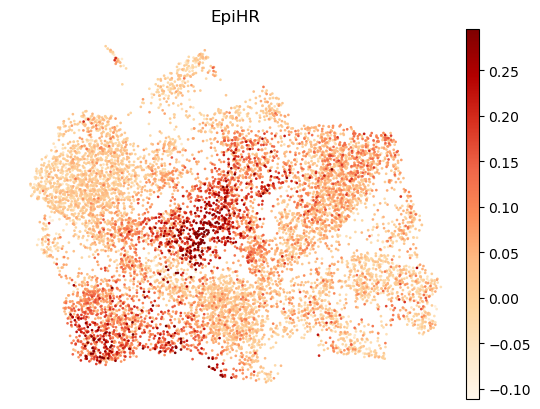

<Figure size 640x480 with 0 Axes>

In [56]:
# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene set scores:")
for feature in gs_process:    
    # Plot and save UMAPs
    sc.pl.umap(adata, color=feature, size=dot_size,
               title=feature_labels[feature], 
               cmap='OrRd', vmax=vmax, frameon=False)
    plt.tight_layout()
    plt.show()

## Stem cell composition

In [5]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata)

In [ ]:
# Set color code and plot barplot
from utils_treatment_HD4246_SG import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_989563/182011732.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['SC_status']


['HD4254', 'HD4272', 'HD4236', 'HD4277', 'HD4309', 'HD4246', 'HD4362']


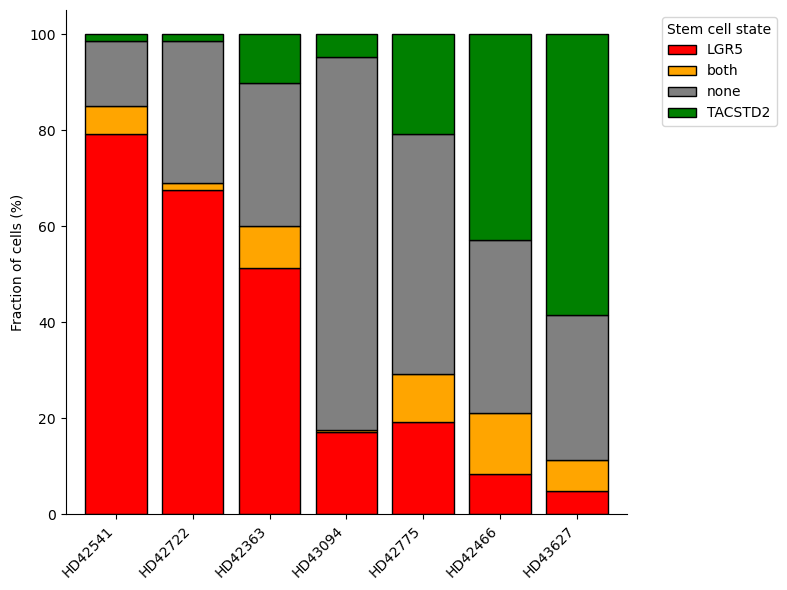

In [ ]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on LGR5 levels in descending order
df = df.sort_values(by='LGR5', ascending=False)

# Sort DataFrame based on predefined donor order
# Swap order of HD43094 and HD42775 to match current Figure panel
order_donor_id = [ # order as in current Figure panel
    'HD4254', 'HD4272', 'HD4236', 'HD4309', 'HD4277', 'HD4246', 'HD4362'
]
# Reorder df by 'donor_id' column
df = df.reindex(order_donor_id)

# Barplot 
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(8, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [75]:
df.to_csv(f"../data_suppl/{accession}_Fig_01i.csv")
df

SC_status,LGR5,both,none,TACSTD2
donor_id,,,,
HD4254,79.069767,5.852713,13.720930,1.356589
HD4272,67.457306,1.518027,29.648956,1.375712
HD4236,51.297297,8.810811,29.729730,10.162162
HD4309,17.138599,0.298063,77.794337,4.769001
HD4277,19.270833,9.895833,50.000000,20.833333
HD4246,8.444962,12.638323,35.993011,42.923704
HD4362,4.719764,6.588004,30.186824,58.505408


## Gene set enrichment TROP2+ vs TROP2- 

This dataset has been analyzed with decoupler version 1.8.0. In the meantime, decoupler has been upgrade to version 2.0.6 (or higher) which was used in more recent datasets.

In [7]:
import decoupler as dc
dc.__version__

'1.8.0'

### Pseudobulk generation

In [8]:
# Add TROP2 status column based on 'TROP2_pos' boolean column
adata.obs['TROP2_status'] = ['TROP2_pos' if x else 'TROP2_neg' for x in adata.obs['TACSTD2_pos']]
adata.obs['TROP2_status'].value_counts()

TROP2_status
TROP2_neg    7828
TROP2_pos    2307
Name: count, dtype: int64

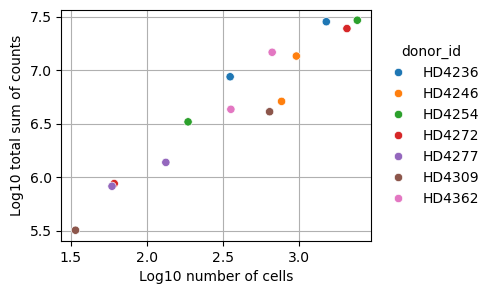

In [13]:
### Generate pseudobulks

# Define minimum number of cells and counts for pseudobulk
min_cells = 20
min_counts = 5e4

### Compute pseudobulk profiles
sample_col = 'donor_id'
group_col = ['TROP2_status']
pdata = dc.get_pseudobulk(
    adata,
    sample_col=sample_col,
    groups_col=group_col,
    layer='counts',
    mode='sum',
    min_cells=min_cells,
    min_counts=min_counts,
)


### Visualize pseudobulk profiles
# Not part of manuscript
dc.plot_psbulk_samples(pdata, groupby=sample_col, figsize=(4, 3))

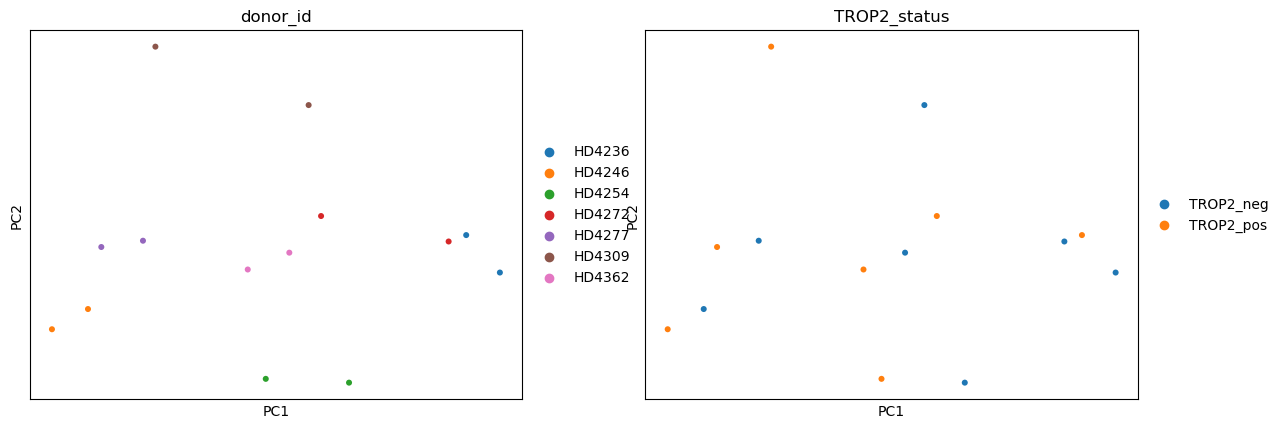

In [ ]:
### Compute PCA on pseudobulk data
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)


### Visualize data on PCA
# Not part of manuscript
sc.pl.pca(pdata, color=[sample_col] + group_col, ncols=2, size=75)

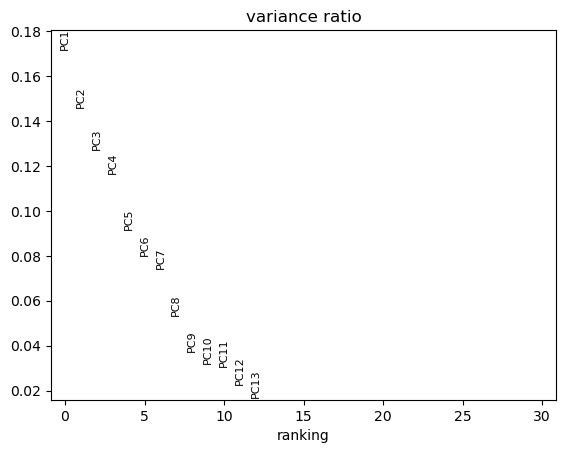

In [17]:
### Plot variance explained by PCs
# Not part of manuscript
sc.pl.pca_variance_ratio(pdata)

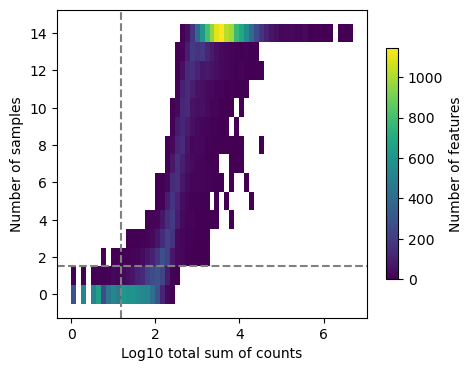

In [18]:
### Filter genes by expression
min_count = 10
min_total_count = 15
dc.plot_filter_by_expr(pdata, group=sample_col, min_count=min_count, min_total_count=min_total_count)
genes = dc.filter_by_expr(pdata, group=sample_col, min_count=min_count, min_total_count=min_total_count)

In [23]:
### Save pseudobulk data
pdata = pdata[:, genes].copy()
print(pdata.shape)
# Remove binary values from obs
del pdata.obs['TACSTD2_pos']
pdata.write_h5ad(os.path.join(dir_data, f"{accession}_pdata.h5ad"))
pdata

(14, 17606)


AnnData object with n_obs × n_vars = 14 × 17606
    obs: 'donor_id', 'TROP2_status', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'donor_id_colors', 'TROP2_status_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

### DGEA on pseudobulks

In [19]:
import decoupler as dc

# # Read pseudobulk data
# accession = "E-MTAB-16585"
# pdata = sc.read_h5ad(os.path.join(dir_data, f"{accession}_pdata.h5ad"))

In [6]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [8]:
# Set up DGEA comparison
design = 'TROP2_status'
design_ref = 'TROP2_neg'

In [9]:
# Create DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata,
    design_factors=design,
    ref_level=[design, design_ref],
    refit_cooks=True,
    inference=inference,
)

/tmp/ipykernel_1893477/2903302091.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(
/omics/groups/OE0285/internal/puschhof/envs/env_saez/lib/python3.10/site-packages/pydeseq2/dds.py:264: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [10]:
# Dispersion and LFC estimation 
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.82 seconds.

Fitting dispersion trend curve...
... done in 10.46 seconds.

Fitting MAP dispersions...
... done in 2.88 seconds.

Fitting LFCs...
... done in 1.85 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 308 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.



In [11]:
### Contrast between conditions

# Replace design underscores with dashes for DeseqStats compatibility
design = design.replace("_", "-")
design_ref = design_ref.replace("_", "-")

### Contrast between conditions
cond = 'TROP2-pos'
print(f"Contrasting with test condition {cond}")
stat_res = DeseqStats(
    dds,
    contrast=[design, cond, design_ref],
    inference=inference,
)
# Compute and depict Wald test results
stat_res.summary()

# Extract results
results_df = stat_res.results_df
results_df.insert(0, 'contrast', f'{cond}_vs_{design_ref}')
results_df.to_csv(f'../data_suppl/{accession}_Fig_01h_pbulk_DGEA_results.csv')
print(f"Number of DE genes with padj < 0.05: {results_df[results_df['padj'] < 0.05].shape[0]}")


Contrasting with test condition TROP2-pos


Running Wald tests...
... done in 0.88 seconds.



Log2 fold change & Wald test p-value: TROP2-status TROP2-pos vs TROP2-neg
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
feature                                                                    
A1CF     192.655892       -0.966513  0.526173 -1.836873  0.066229  0.438966
A4GALT     6.048648        1.783858  0.958660  1.860783  0.062775       NaN
AAAS      47.336810       -0.031104  0.238795 -0.130254  0.896366       NaN
AACS      89.764849       -0.257694  0.302770 -0.851122  0.394702       NaN
AADAC      5.709376        0.150508  0.810981  0.185588  0.852768       NaN
...             ...             ...       ...       ...       ...       ...
ZXDB      17.867646        0.430274  0.385075  1.117377  0.263833       NaN
ZXDC     225.526607        0.080429  0.325612  0.247008  0.804902  0.938603
ZYG11B   121.010936       -0.095724  0.204543 -0.467989  0.639792       NaN
ZYX      197.456686        0.833989  0.299803  2.781788  0.005406  0.128690
ZZEF1    221.7

Plotting results as volcano plot


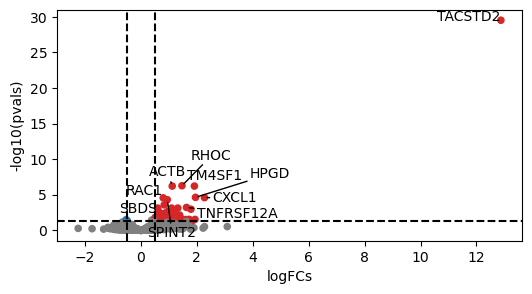

In [33]:
### Plot volcano plot
# Not part of manuscript
print("Plotting results as volcano plot")
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=10,
    figsize=(6, 3),
)

### Enrichment of custom gene sets

In [65]:
# Extract gene set collection from anndata object
print(f"Extract custom gene sets from adata.uns slot")
net = adata.uns['gene_sets']

# Rename for compatibility
net.rename(columns={'gene_set': 'geneset', 'gene': 'genesymbol'}, inplace=True)
net.head(2)

Extract custom gene sets from adata.uns slot


,geneset,genesymbol,weight
0,score_YAP,TSC22D1,1
1,score_YAP,SBDS,1


In [66]:
# Run gene set network check
import warnings

def pre_network_checks(net, source, target, weight, label):
    ### Network checks
    if source not in net.columns:
        raise ValueError(f"Source column {source} not found in network")
    if target not in net.columns:
        raise ValueError(f"Target column {target} not found in network")
    if weight not in net.columns:
        warnings.warn(f"Weight column {weight} not found in network. Setting to None.")
        weight = None
    # Remove duplicate entries if available
    net = net[~net.duplicated([source, target])]
    # Check if gene list is non-zero
    if net.shape[0] == 0:
        warnings.warn(f"No pathways found in network {label}. Skipping...")
    # Check for each geneset if gene overlap is > 5. Otherwise exclude geneset.
    for geneset in net[source].unique():
        if len(set(net[net[source] == geneset][target]).intersection(adata.var_names)) < 5:
            warnings.warn(f"Skipping {geneset} (less than 5 overlapping genes)")
            net = net[net[source] != geneset]
    # Return if no genesets are left
    if net.shape[0] == 0:
        raise ValueError(f"No pathways found in network {label}. Skipping...")
    else:
        return net


# Define parameters
source='geneset'
target='genesymbol'
weight='weight'
label='custom_gene_sets'

# Run network checks
net = pre_network_checks(
    net, 
    source=source, 
    target=target, 
    weight=weight, 
    label=label
)

/tmp/ipykernel_1893477/1904504389.py:21: UserWarning: Skipping score_Mex3a_Barriga (less than 5 overlapping genes)
  warnings.warn(f"Skipping {geneset} (less than 5 overlapping genes)")


In [ ]:
# Subset to gene sets of interest
from utils_treatment_HD4246_SG import custom_subset
if custom_subset is not None:
    # print(f"Subset custom gene sets to {custom_subset}")
    net = net[net['geneset'].isin(custom_subset)] 
    adata.uns['gene_sets'] = net

Subset custom gene sets to ['score_coreHR', 'score_epiHR', 'score_Lgr5_Batlle', 'score_Wnt_Batlle', 'score_mKi67_Batlle', 'score_Mucosecreeting', 'score_Paneth_Cells', 'score_Enteroendocrine', 'score_Secretory_Progenitors', 'score_Goblet_Cells', 'score_Lgr5_signature', 'score_LGR5Hi_MEX3AHi', 'score_LGR5hi_MEX3Alow', 'score_YAP_direct_targets', 'score_fetal_Moorman', 'score_squamous_Moorman', 'score_neuroendocrine_Moorman', 'score_YAP', 'score_Lgr5', 'score_fetal', 'score_POLR1A_High', 'score_Label_Retaining_Cells', 'score_Proliferation_(Merlos)', 'score_Immature_enterocytes_(Smillie)', 'score_Revival_SCs_(Vazquez)', 'score_Revival_SCs_(Ayyaz)', 'score_YAP_22_(Wang)', 'score_Basal_PDAC_(Raghavan)']


In [70]:
# Turn DGEA results into anndata object
results_df.reset_index(inplace=True)
results_df.rename(columns={'feature': 'names'}, inplace=True)
df_pivot = results_df.pivot(index='contrast', columns='names', values='stat')
dgea = anndata.AnnData(
    X=df_pivot.values,
    obs=pd.DataFrame(index=df_pivot.index),
    var=pd.DataFrame(index=df_pivot.columns),
)
dgea.raw = dgea

In [71]:
# Run ULM method on custom gene sets
method = "ulm"
print(f"Run enrichment method {method} on custom gene sets")
dc.run_ulm(
    mat=dgea, 
    net=net, 
    source=source, 
    target=target, 
    weight=weight
)
# Extract activity scores as anndata object
acts = dc.get_acts(
    dgea, 
    obsm_key=f'{method}_estimate'
)

Run enrichment method ulm on custom gene sets


In [72]:
### Clean-up activity matrix
# Set activity values of inf to maximum observed
acts_v = acts.X.ravel()
max_e = np.nanmax(acts_v[np.isfinite(acts_v)])
acts.X[~np.isfinite(acts.X)] = max_e

In [73]:
# Extract activity scores and pvalues into DataFrame for plotting
# Activity scores
df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs.index)
df = df.reset_index().melt(id_vars='contrast', var_name='names', value_name='acts')
# p-values
df_pval = pd.DataFrame(acts.obsm[f'{method}_pvals'], columns=acts.var_names, index=acts.obs.index)
df_pval = df_pval.reset_index().melt(id_vars='contrast', var_name='names', value_name='pvalue')
# Merge df and pval_df
df = pd.merge(df, df_pval, on=['contrast', 'names'])        
df = df.sort_values(by='acts', ascending=False)

# Use publication-ready gene set names
from utils_genelist import gs_names_for_pub
df['names'] = df['names'].replace(gs_names_for_pub)

# Report number of significant results
print(f"Number of significant results: {df[df['pvalue'] < 0.05].shape[0]}")
df.to_csv(os.path.join('../data_suppl', f"{accession}_Fig_01h_ULM_acts.csv"))
df

Number of significant results: 11


,contrast,names,acts,pvalue
9,TROP2-pos_vs_TROP2-neg,YAP (Gregorieff et al.),19.956846,1.217425e-87
10,TROP2-pos_vs_TROP2-neg,coreHR (Cañellas-Socias et al.),17.156698,1.908151e-65
11,TROP2-pos_vs_TROP2-neg,epiHR (Cañellas-Socias et al.),10.974578,6.238662e-28
12,TROP2-pos_vs_TROP2-neg,Fetal (Mustata et al.),9.929107,3.579000e-23
0,TROP2-pos_vs_TROP2-neg,LGR5Hi MEX3AHi (Álvarez-Varela et al.),6.562479,5.439726e-11
1,TROP2-pos_vs_TROP2-neg,LGR5hi MEX3Alow (Álvarez-Varela et al.),5.559093,2.751189e-08
14,TROP2-pos_vs_TROP2-neg,mKi67 (Basak et al.),2.600368,9.320168e-03
16,TROP2-pos_vs_TROP2-neg,Squamous (Moorman et al.),2.299230,2.150353e-02
6,TROP2-pos_vs_TROP2-neg,POLR1A High (Morral et al.),0.914236,3.606056e-01
13,TROP2-pos_vs_TROP2-neg,Fetal (Moorman et al.),-0.022362,9.821594e-01


For the manuscript, the bar plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_1893477/588082690.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


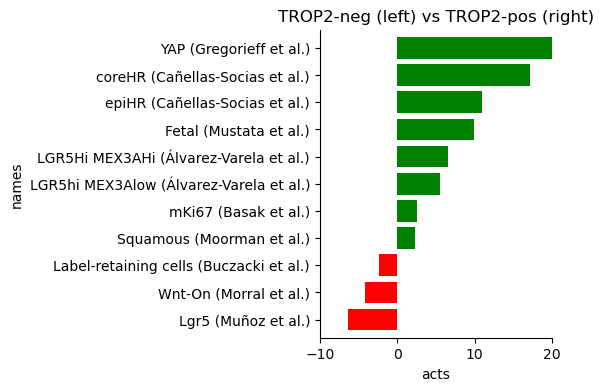

In [79]:
# Make bar plot of significant results
df_sign = df[df['pvalue'] < 0.05].copy()

# Add color group
df_sign["direction"] = np.where(df_sign["acts"] > 0, "positive", "negative")
bar_colors = np.where(
    df_sign["acts"] > 0, 
    color_code['TROP2_status']['colors']['positive'], 
    color_code['TROP2_status']['colors']['negative']
)  

height = df_sign.shape[0]/3 if df_sign.shape[0] > 12 else 4
        

fig, ax = plt.subplots(figsize=(3, height))
dc.plot_barplot_df(
    df_sign,
    x="acts",
    y="names",
    color=bar_colors[::-1],
    title="TROP2-neg (left) vs TROP2-pos (right)",
    figsize=(3, height),
    ax=ax,
)
ax.set_xlim(-10, 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Get data from arrayExpress: VAKPS VKPN MDO tumors

In [80]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16835"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16835 in: ../data_arrayExpress/E-MTAB-16835
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16835
      Inferred 2 dataset representations:
      - epi (full prefix: AKPS_KPN_epi)
      - full (full prefix: AKPS_KPN_full)
      No dataset specified. Automatically selected for in-memory loading: epi (full prefix: AKPS_KPN_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_full.h5ad
      Loading selected dataset from disk: E-MTAB-16835/E-MTAB-16835_epi.h5ad


AnnData object with n_obs × n_vars = 1573 × 18791
    obs: 'sample_id', 'library_id', 'line', 'replicate', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## UMAP representation

UMAP was not changed after doing proper QC on dataset... Exchange in Ext Fig 2d

In [ ]:
adata.obs.columns

Index(['sample_id', 'library_id', 'line', 'replicate', 'leiden'], dtype='object')

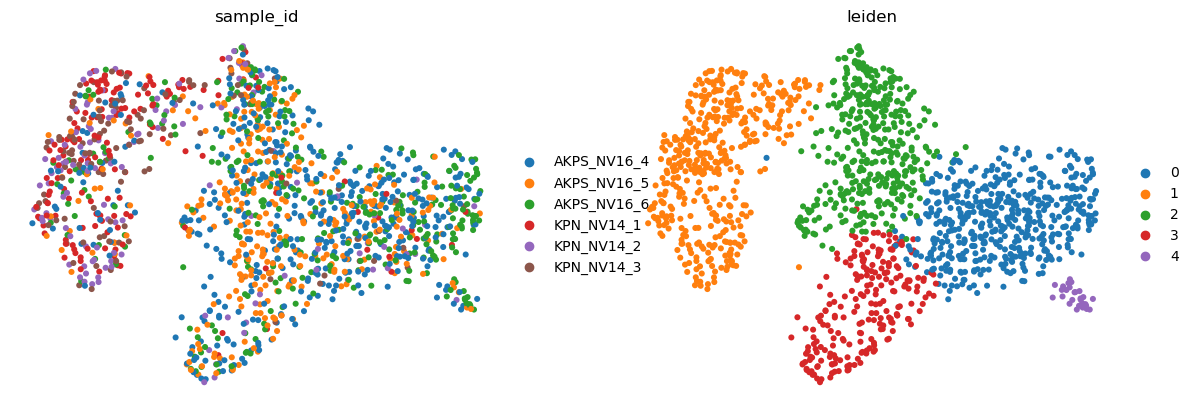

In [ ]:
# # Leiden UMAP
# adata.obs['leiden'] = adata.obs['leiden'].astype(str)
# sc.pl.umap(adata, color=['sample_id', 'leiden'], frameon=False, title=None)

In [ ]:
# Add annotation to dataset
from utils_biobank_subcut import anno_leiden_dict_epi as anno_leiden_dict

adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# Order annotation levels by leiden cluster number
adata.obs['anno'] = pd.Categorical(
    adata.obs['anno'],
    categories=[anno_leiden_dict['labels'][f'{i}'] for i in range(len(anno_leiden_dict['labels']))],
    ordered=True
)

## Feature expression on UMAP

UMAPs of gene expression patterns:


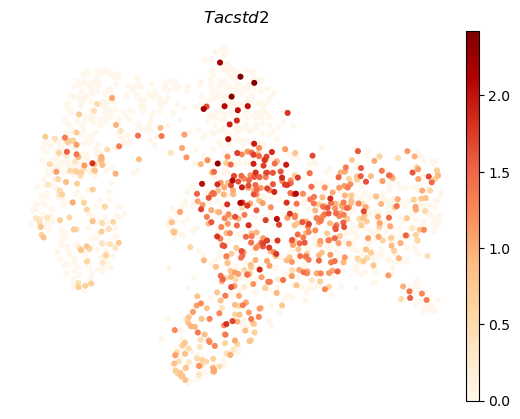

<Figure size 640x480 with 0 Axes>

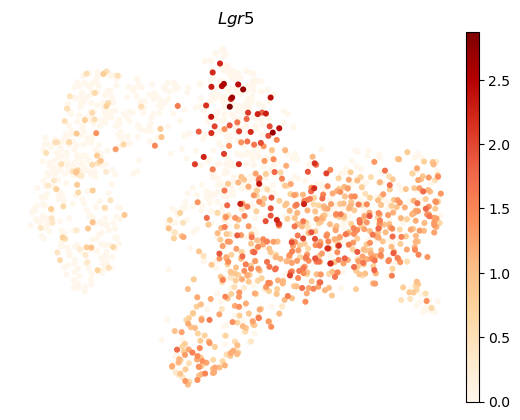

<Figure size 640x480 with 0 Axes>

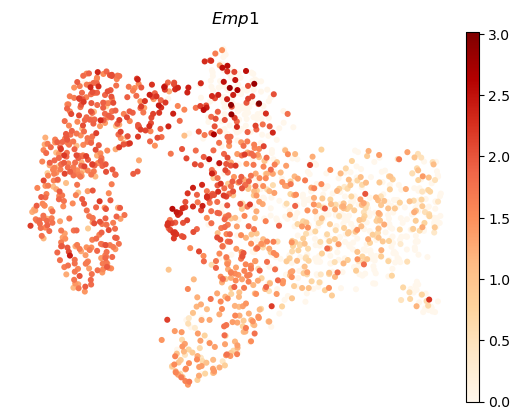

<Figure size 640x480 with 0 Axes>

In [86]:
# Features to plot
features = ['Tacstd2', 'Lgr5', 'Emp1']

# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        # size=dot_size, 
        cmap='OrRd', 
        # vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    plt.tight_layout()
    plt.show()

## Stem cell composition

In [87]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata, species="Mm")

In [89]:
# Set color code and plot barplot
from utils_VAKPS_VKPN import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

In [91]:
adata.obs

,sample_id,library_id,line,replicate,leiden,Lgr5_pos,Tacstd2_pos,SC_status
AAACGAACAGCACAGA-1-0,AKPS_NV16_5,S01,AKPS,NaN,2,False,False,none
AAACGCTTCGAGAACG-1-0,AKPS_NV16_4,S01,AKPS,NaN,3,True,True,both
AAAGAACTCATATGGC-1-0,AKPS_NV16_4,S01,AKPS,NaN,0,False,False,none
AAAGGATCATTACGGT-1-0,KPN_NV14_1,S01,KPN,NaN,1,False,False,none
AAAGGATGTTGCCAAT-1-0,AKPS_NV16_6,S01,AKPS,NaN,0,True,True,both
...,...,...,...,...,...,...,...,...
TTTGGTTAGTGGCAGT-1-0,AKPS_NV16_4,S01,AKPS,NaN,0,True,True,both
TTTGTTGAGTGCAGCA-1-0,AKPS_NV16_5,S01,AKPS,NaN,3,True,True,both
TTTGTTGCAGGACGAT-1-0,AKPS_NV16_6,S01,AKPS,NaN,0,True,True,both
TTTGTTGGTTCCGTTC-1-0,AKPS_NV16_6,S01,AKPS,NaN,3,True,False,Lgr5


For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

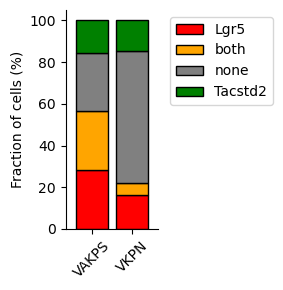

In [97]:
groupby = 'line'

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Map line identity
line_mapping = {
    'AKPS': 'VAKPS',
    'KPN': 'VKPN',
}
df.index = df.index.map(line_mapping)

# Barplot 
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(3, 3), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_tick_params(rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [98]:
df.to_csv(f"../data_suppl/{accession}_Fig_01m.csv")
df

SC_status,Lgr5,both,none,Tacstd2
line,,,,
VAKPS,28.213978,28.386540,27.868852,15.53063
VKPN,16.183575,5.797101,63.285024,14.73430
